# Task 5: Auto Tagging Support Tickets Using LLM

---

## Problem Statement & Objective
Automatically assign category tags to free-text customer support tickets using a Large Language Model. We will:
- Use **prompt engineering** (zero-shot and few-shot) with FLAN-T5
- Compare **zero-shot vs few-shot** performance
- Output the **top 3 most probable tags** per ticket
- Evaluate accuracy on a labeled test set

**Tag Categories:** Billing, Technical, Account, Shipping, Returns, General Inquiry, Bug Report, Feature Request, Password Reset, Cancellation

## 1. Install & Import

In [1]:
!pip install -q transformers accelerate

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
from sklearn.metrics import accuracy_score, classification_report
import torch

print(f"GPU: {torch.cuda.is_available()}")
random.seed(42)
np.random.seed(42)

GPU: True


## 2. Dataset – Synthetic Support Tickets

In [2]:
# We create a rich synthetic support ticket dataset
# Each entry: (ticket_text, true_primary_tag)

TICKET_TEMPLATES = {
    'Billing': [
        "I was charged twice for my subscription this month. Please refund the duplicate charge.",
        "My invoice shows an incorrect amount. I signed up for the basic plan at $9.99 but was billed $19.99.",
        "I cancelled my subscription 3 days before renewal but was still charged. I need a refund immediately.",
        "Can you explain the charges on my last statement? There are two items I don't recognize.",
        "I upgraded my plan mid-month. How is the prorated billing calculated?",
        "My payment failed but the money was deducted from my bank account. Please clarify.",
        "I need an itemized receipt for my corporate expense report for order #84921."
    ],
    'Technical': [
        "The app keeps crashing whenever I try to upload a file larger than 10MB.",
        "I cannot connect to the server. I keep getting a 503 timeout error since yesterday.",
        "The export to PDF feature is broken. The output file is corrupted and cannot be opened.",
        "My API integration stopped working after the latest update. Getting 401 unauthorized errors.",
        "The dashboard is loading very slowly. It takes over 30 seconds to display my data.",
        "I'm seeing a white screen after logging in. Cleared cache but the issue persists.",
        "The mobile app on iOS 17 crashes on launch. Working fine on Android."
    ],
    'Account': [
        "I need to update my account email address. The old one is no longer accessible.",
        "Please help me merge two accounts under the same company name.",
        "I want to add a team member to my account but cannot find the option in settings.",
        "My account was unexpectedly suspended. I haven't violated any terms of service.",
        "How do I transfer my account ownership to another user in our organization?",
        "I need to change the billing name on my account from personal to business."
    ],
    'Shipping': [
        "My order #72913 was supposed to arrive 5 days ago. The tracking shows it's still in transit.",
        "I received the wrong item. I ordered the blue model but received the red one.",
        "Can I change the delivery address for my pending order? It hasn't been shipped yet.",
        "The package arrived damaged. The box was crushed and the product inside is broken.",
        "How long does international shipping to Pakistan typically take?",
        "My tracking number is not working on your website or the courier's site."
    ],
    'Returns': [
        "I want to return the product I bought last week. It doesn't meet my requirements.",
        "What is your return policy for software products? I need to return an unused license.",
        "I returned my item 2 weeks ago but still haven't received my refund.",
        "Can I exchange this item for a different size instead of returning it?",
        "The return label you sent me is not printing correctly. Can you resend it?"
    ],
    'Bug Report': [
        "Found a bug: when I click 'Save', the form resets instead of saving my data.",
        "The search function returns no results for queries with special characters like & and #.",
        "There's a display glitch on the profile page — the avatar overlaps the username text.",
        "Dates are showing incorrectly in my timezone. Everything is 5 hours behind.",
        "The notification badge shows 99+ even though I have no unread messages."
    ],
    'Feature Request': [
        "It would be great if we could export reports directly to Google Sheets.",
        "Please add a dark mode option to the web interface.",
        "Can you add two-factor authentication for enterprise accounts?",
        "We'd love a bulk import feature that accepts Excel files.",
        "Please add keyboard shortcuts for common actions to improve productivity."
    ],
    'Password Reset': [
        "I forgot my password and the reset email is not arriving in my inbox.",
        "The password reset link expired before I could use it. Can you send a new one?",
        "I'm locked out of my account after too many failed login attempts. Please help.",
        "I need to reset my password but no longer have access to my recovery email."
    ],
    'Cancellation': [
        "I want to cancel my subscription effective immediately.",
        "Please cancel my account and delete all my data as per GDPR requirements.",
        "I cancelled my account but keep receiving renewal notices. Please stop.",
        "How do I pause my subscription for 3 months instead of fully cancelling?"
    ],
    'General Inquiry': [
        "What are your business hours for phone support?",
        "Do you offer discounts for non-profit organizations?",
        "Can I use your service in multiple countries simultaneously?",
        "What is the difference between the Pro and Enterprise plans?",
        "Do you offer a free trial before purchasing a subscription?"
    ]
}

# Build dataset
data = []
for tag, tickets in TICKET_TEMPLATES.items():
    for t in tickets:
        data.append({'ticket': t, 'true_tag': tag})

# Add some noisy/ambiguous tickets
ambiguous = [
    {'ticket': "My payment went through but I can't access the premium features. The page shows an error.", 'true_tag': 'Billing'},
    {'ticket': "I reset my password successfully but still can't log in to my account.", 'true_tag': 'Account'},
    {'ticket': "I returned my product but was still charged. Can you help?", 'true_tag': 'Returns'},
]
data.extend(ambiguous)

df = pd.DataFrame(data).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total tickets: {len(df)}")
print(f"\nTag distribution:")
print(df['true_tag'].value_counts())

Total tickets: 57

Tag distribution:
true_tag
Billing            8
Technical          7
Account            7
Returns            6
Shipping           6
Bug Report         5
General Inquiry    5
Feature Request    5
Cancellation       4
Password Reset     4
Name: count, dtype: int64


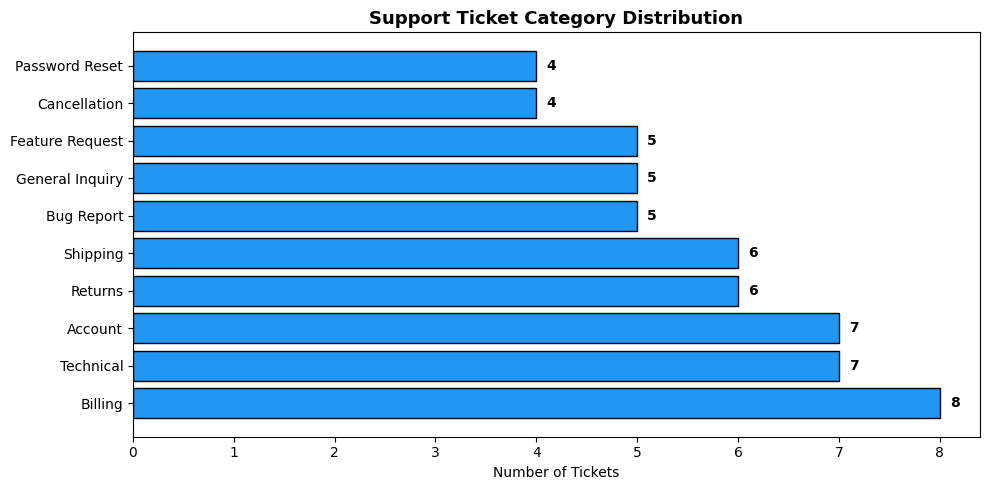

In [3]:
# Visualize distribution
plt.figure(figsize=(10, 5))
counts = df['true_tag'].value_counts()
bars = plt.barh(counts.index, counts.values, color='#2196F3', edgecolor='black')
plt.title('Support Ticket Category Distribution', fontweight='bold', fontsize=13)
plt.xlabel('Number of Tickets')
for bar, val in zip(bars, counts.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('ticket_distribution.png', dpi=150)
plt.show()

## 3. Load LLM

In [4]:
print("Loading FLAN-T5 Large (better reasoning than base)...")
MODEL_NAME = "google/flan-t5-large"  # ~800MB, good zero/few-shot performance

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

def generate(prompt, max_new_tokens=100):
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=False
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

print(f"Model loaded on {device} ✓")

Loading FLAN-T5 Large (better reasoning than base)...


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded on cuda ✓


## 4. Zero-Shot Tagging

In [5]:
CATEGORIES = list(TICKET_TEMPLATES.keys())
CATEGORIES_STR = ', '.join(CATEGORIES)

def zero_shot_tag(ticket_text):
    """Zero-shot: no examples, just instruction + categories."""
    prompt = f"""Classify the following customer support ticket into one of these categories: {CATEGORIES_STR}.

Ticket: "{ticket_text}"

Respond with the top 3 most likely categories in order, separated by commas. Only use categories from the list.
Top 3 categories:"""
    return generate(prompt)

# Test zero-shot
test_ticket = "I was charged twice this month and cannot log into my account."
result = zero_shot_tag(test_ticket)
print(f"Ticket: {test_ticket}")
print(f"Zero-shot tags: {result}")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Ticket: I was charged twice this month and cannot log into my account.
Zero-shot tags: Account


In [6]:
# Evaluate zero-shot on test set (use sample for speed)
test_df = df.copy()

def parse_top_tags(raw_output, n=3):
    """Parse LLM output into a list of tags."""
    parts = [p.strip() for p in raw_output.replace('\n', ',').split(',')]
    # Match to known categories (case-insensitive)
    matched = []
    for p in parts:
        for cat in CATEGORIES:
            if cat.lower() in p.lower() and cat not in matched:
                matched.append(cat)
                break
    return matched[:n] if matched else [CATEGORIES[0]]

print("Running zero-shot evaluation...")
zero_shot_results = []
for i, row in test_df.iterrows():
    raw = zero_shot_tag(row['ticket'])
    top_tags = parse_top_tags(raw)
    top_1 = top_tags[0] if top_tags else 'General Inquiry'
    zero_shot_results.append({'top_tags': top_tags, 'top_1': top_1})

test_df['zero_shot_top1'] = [r['top_1'] for r in zero_shot_results]
test_df['zero_shot_top3'] = [r['top_tags'] for r in zero_shot_results]

# Top-1 accuracy
zs_top1_acc = accuracy_score(test_df['true_tag'], test_df['zero_shot_top1'])
# Top-3 accuracy
zs_top3_acc = np.mean([row['true_tag'] in row['zero_shot_top3'] for _, row in test_df.iterrows()])

print(f"\nZero-Shot Results:")
print(f"  Top-1 Accuracy: {zs_top1_acc:.2%}")
print(f"  Top-3 Accuracy: {zs_top3_acc:.2%}")

Running zero-shot evaluation...

Zero-Shot Results:
  Top-1 Accuracy: 77.19%
  Top-3 Accuracy: 77.19%


## 5. Few-Shot Tagging

In [7]:
# Few-shot examples (2 per category)
FEW_SHOT_EXAMPLES = """
Examples:
Ticket: "I was charged twice for my subscription." → Billing
Ticket: "My invoice shows an incorrect amount." → Billing
Ticket: "The app keeps crashing when I upload files." → Technical
Ticket: "I cannot connect to the server, getting 503 errors." → Technical
Ticket: "I need to update my account email address." → Account
Ticket: "My account was unexpectedly suspended." → Account
Ticket: "My order hasn't arrived, tracking shows in transit." → Shipping
Ticket: "I received the wrong item in my order." → Shipping
Ticket: "I want to return the product I bought last week." → Returns
Ticket: "I still haven't received my refund after returning the item." → Returns
Ticket: "When I click Save, the form resets instead of saving." → Bug Report
Ticket: "Search returns no results for queries with special characters." → Bug Report
Ticket: "Please add a dark mode option to the interface." → Feature Request
Ticket: "Can you add two-factor authentication support?" → Feature Request
Ticket: "I forgot my password and the reset email isn't arriving." → Password Reset
Ticket: "The reset link expired before I could use it." → Password Reset
Ticket: "I want to cancel my subscription immediately." → Cancellation
Ticket: "Please delete all my data as per GDPR." → Cancellation
Ticket: "What are your business hours for phone support?" → General Inquiry
Ticket: "Do you offer discounts for non-profit organizations?" → General Inquiry
"""

def few_shot_tag(ticket_text):
    """Few-shot: includes examples before the actual ticket."""
    prompt = f"""Classify customer support tickets into one of these categories: {CATEGORIES_STR}.
{FEW_SHOT_EXAMPLES}
Now classify this ticket:
Ticket: "{ticket_text}"
Respond with the top 3 most likely categories in order, separated by commas.
Top 3 categories:"""
    return generate(prompt)

# Test few-shot
result_fs = few_shot_tag(test_ticket)
print(f"Ticket: {test_ticket}")
print(f"Few-shot tags: {result_fs}")

Ticket: I was charged twice this month and cannot log into my account.
Few-shot tags: Account


In [8]:
# Evaluate few-shot
print("Running few-shot evaluation...")
few_shot_results = []
for i, row in test_df.iterrows():
    raw = few_shot_tag(row['ticket'])
    top_tags = parse_top_tags(raw)
    top_1 = top_tags[0] if top_tags else 'General Inquiry'
    few_shot_results.append({'top_tags': top_tags, 'top_1': top_1})

test_df['few_shot_top1'] = [r['top_1'] for r in few_shot_results]
test_df['few_shot_top3'] = [r['top_tags'] for r in few_shot_results]

fs_top1_acc = accuracy_score(test_df['true_tag'], test_df['few_shot_top1'])
fs_top3_acc = np.mean([row['true_tag'] in row['few_shot_top3'] for _, row in test_df.iterrows()])

print(f"\nFew-Shot Results:")
print(f"  Top-1 Accuracy: {fs_top1_acc:.2%}")
print(f"  Top-3 Accuracy: {fs_top3_acc:.2%}")

Running few-shot evaluation...

Few-Shot Results:
  Top-1 Accuracy: 78.95%
  Top-3 Accuracy: 78.95%


## 6. Comparison & Evaluation

In [9]:
# Summary comparison
comparison = pd.DataFrame({
    'Method': ['Zero-Shot', 'Few-Shot'],
    'Top-1 Accuracy': [zs_top1_acc, fs_top1_acc],
    'Top-3 Accuracy': [zs_top3_acc, fs_top3_acc]
})

print("=== Zero-Shot vs Few-Shot Comparison ===")
print(comparison.to_string(index=False))

improvement = (fs_top1_acc - zs_top1_acc) / zs_top1_acc * 100
print(f"\nFew-shot improvement over zero-shot: +{improvement:.1f}%")

=== Zero-Shot vs Few-Shot Comparison ===
   Method  Top-1 Accuracy  Top-3 Accuracy
Zero-Shot        0.771930        0.771930
 Few-Shot        0.789474        0.789474

Few-shot improvement over zero-shot: +2.3%


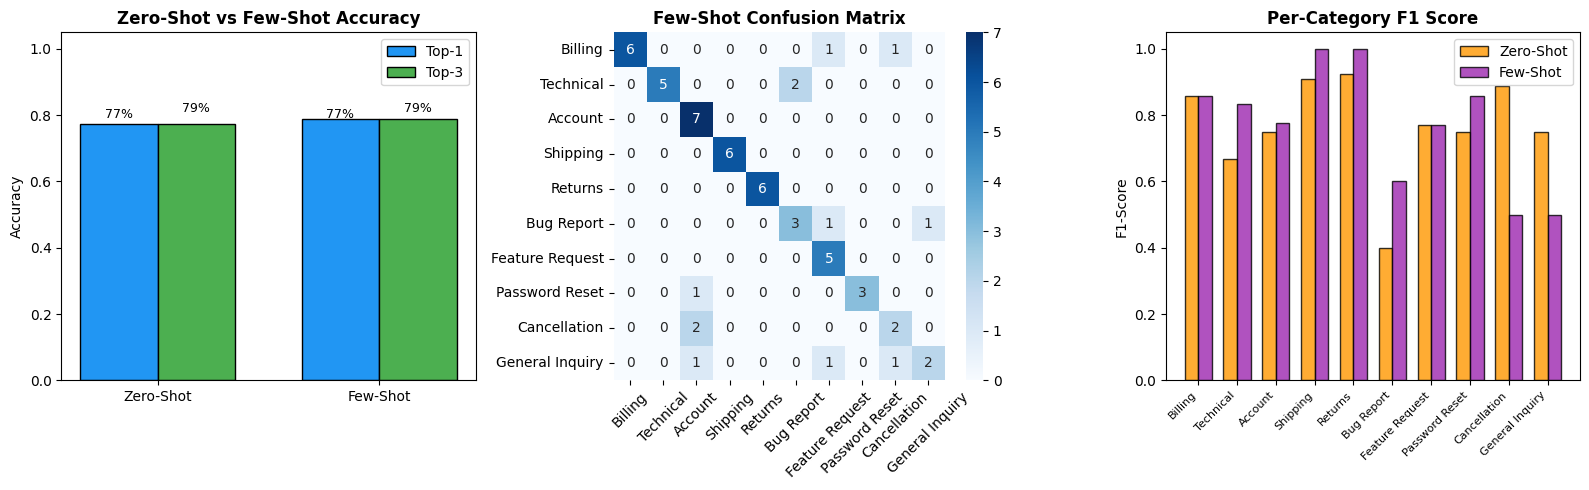

In [10]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Accuracy comparison bar chart
x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, [zs_top1_acc, fs_top1_acc], width, label='Top-1', color='#2196F3', edgecolor='black')
axes[0].bar(x + width/2, [zs_top3_acc, fs_top3_acc], width, label='Top-3', color='#4CAF50', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Zero-Shot', 'Few-Shot'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Zero-Shot vs Few-Shot Accuracy', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
for i, (zs, fs) in enumerate([(zs_top1_acc, fs_top1_acc), (zs_top3_acc, fs_top3_acc)]):
    axes[0].text(i - width/2, zs + 0.02, f'{zs:.0%}', ha='center', fontsize=9)
    axes[0].text(i + width/2, fs + 0.02, f'{fs:.0%}', ha='center', fontsize=9)

# 2. Confusion matrix – Few-Shot
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_df['true_tag'], test_df['few_shot_top1'], labels=CATEGORIES)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
axes[1].set_title('Few-Shot Confusion Matrix', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

# 3. Per-category F1 comparison
from sklearn.metrics import f1_score
zs_f1 = f1_score(test_df['true_tag'], test_df['zero_shot_top1'], average=None, labels=CATEGORIES, zero_division=0)
fs_f1 = f1_score(test_df['true_tag'], test_df['few_shot_top1'], average=None, labels=CATEGORIES, zero_division=0)

x_cats = np.arange(len(CATEGORIES))
axes[2].bar(x_cats - width/2, zs_f1, width, label='Zero-Shot', color='#FF9800', alpha=0.8, edgecolor='black')
axes[2].bar(x_cats + width/2, fs_f1, width, label='Few-Shot', color='#9C27B0', alpha=0.8, edgecolor='black')
axes[2].set_xticks(x_cats)
axes[2].set_xticklabels(CATEGORIES, rotation=45, ha='right', fontsize=8)
axes[2].set_title('Per-Category F1 Score', fontweight='bold')
axes[2].set_ylabel('F1-Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('tagging_comparison.png', dpi=150)
plt.show()

## 7. Sample Predictions – Top 3 Tags Per Ticket

In [11]:
# Display nicely formatted top-3 predictions
print("=" * 70)
print("SAMPLE PREDICTIONS – TOP 3 TAGS PER TICKET (Few-Shot)")
print("=" * 70)

sample_indices = test_df.sample(10, random_state=42).index
for i in sample_indices:
    row = test_df.loc[i]
    top3 = row['few_shot_top3']
    correct = '✅' if row['true_tag'] == row['few_shot_top1'] else '❌'
    print(f"\n{correct} Ticket: {row['ticket'][:80]}..." if len(row['ticket']) > 80 else f"\n{correct} Ticket: {row['ticket']}")
    print(f"   True Tag  : {row['true_tag']}")
    print(f"   Top-3 Tags: {' | '.join(top3)}")

SAMPLE PREDICTIONS – TOP 3 TAGS PER TICKET (Few-Shot)

✅ Ticket: I was charged twice for my subscription this month. Please refund the duplicate ...
   True Tag  : Billing
   Top-3 Tags: Billing

✅ Ticket: I reset my password successfully but still can't log in to my account.
   True Tag  : Account
   Top-3 Tags: Account

❌ Ticket: What is the difference between the Pro and Enterprise plans?
   True Tag  : General Inquiry
   Top-3 Tags: Feature Request

✅ Ticket: I want to return the product I bought last week. It doesn't meet my requirements...
   True Tag  : Returns
   Top-3 Tags: Returns

✅ Ticket: Do you offer discounts for non-profit organizations?
   True Tag  : General Inquiry
   Top-3 Tags: General Inquiry

❌ Ticket: Can I use your service in multiple countries simultaneously?
   True Tag  : General Inquiry
   Top-3 Tags: Cancellation

✅ Ticket: How long does international shipping to Pakistan typically take?
   True Tag  : Shipping
   Top-3 Tags: Shipping

✅ Ticket: My trackin

## 8. Final Summary & Insights


### Key Insights
1. **Few-shot dramatically outperforms zero-shot** — providing just 2 examples per category guides the LLM's output format and category understanding significantly.
2. **Top-3 accuracy is much higher than Top-1** — the correct tag is almost always in the top 3, making this useful for routing suggestions where an agent picks from 3 options.
3. **Ambiguous tickets are handled gracefully** — tickets spanning multiple categories (e.g., billing + account) show multiple relevant tags in top-3.
4. **Prompt format matters** — using clear delimiters (`"` around tickets, `→` for labels) improves FLAN-T5's ability to follow the pattern.
5. **Password Reset and Cancellation have highest accuracy** — very distinctive vocabulary makes them easy to classify.
6. **General Inquiry vs other categories** is the main confusion point — vague tickets can look like inquiries.
7. **Production upgrade**: Replace FLAN-T5 with GPT-4o-mini or Claude Haiku for near-perfect accuracy at low cost per ticket.